In [1]:
#!gcloud auth login
!gcloud auth list
!gcloud config set account 376231489344-compute@developer.gserviceaccount.com
#!gcloud config set account admin@brendanills.altostrat.com
!gcloud auth list


                  Credentialed Accounts
ACTIVE  ACCOUNT
*       376231489344-compute@developer.gserviceaccount.com
        admin@brendanhills.altostrat.com

To set the active account, run:
    $ gcloud config set account `ACCOUNT`

Updated property [core/account].
                  Credentialed Accounts
ACTIVE  ACCOUNT
*       376231489344-compute@developer.gserviceaccount.com
        admin@brendanhills.altostrat.com

To set the active account, run:
    $ gcloud config set account `ACCOUNT`



In [2]:
#%pip install google-cloud-translate --upgrade


In [3]:

PROJECT_ID = "uk-bh-experiments-argolis"  # @param {type:"string"}
REGION = "us-central1"  # @param {type: "string"}
DATASET_ID = "schema_mapping"  # @param {type:"string"}

In [4]:
#import bigframes.dataframe
import vertexai.preview
from vertexai.preview import generative_models
from vertexai.preview.generative_models import GenerativeModel, Part
from vertexai.preview.language_models import TextGenerationModel

from google.api_core.client_options import ClientOptions
import io
import PIL
import re
import json
import pandas as pd
from google.cloud import storage
import base64
from io import BytesIO

vertexai.init(project=PROJECT_ID, location=REGION)

generation_config={
        "max_output_tokens": 1000,
        "temperature": 0.4,
        "top_p": 1,
        "top_k": 20
    }

safety_settings={
          generative_models.HarmCategory.HARM_CATEGORY_HATE_SPEECH: generative_models.HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE,
          generative_models.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: generative_models.HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE,
          generative_models.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: generative_models.HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE,
          generative_models.HarmCategory.HARM_CATEGORY_HARASSMENT: generative_models.HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE,
    }

model_gemini_pro_10 = GenerativeModel("gemini-1.0-pro-001", generation_config=generation_config, safety_settings=safety_settings, )
model_gemini_pro_vision_10 = GenerativeModel("gemini-1.0-pro-vision", generation_config=generation_config, safety_settings=safety_settings)
model_gemini_experimental_vision = GenerativeModel("gemini-experimental", generation_config=generation_config, safety_settings=safety_settings)



In [5]:
import io
import re
import json
import pandas as pd
from google.cloud import storage
from IPython.display import display, Markdown
import pprint
import requests
import textwrap

##
def convertWebp2PNG(webp_img):
  converted = webp_img.convert('RGB')
  return converted


def convertWebP2PngFromURL(url) :
  img = PIL.Image.open(requests.get(url, stream=True).raw,  "image.webp")
  converted = img.convert('RGB')
  return converted


def convertWebPtoJPG(webp_img):
  buf = io.BytesIO()
  webp_img.save(buf, format='JPEG')
  byte_im = buf.getvalue()
  return  PIL.Image.open(io.BytesIO(byte_im))


def convertWebPtoVertexImage(webp_img):
  buf = io.BytesIO()
  webp_img.save(buf, format='JPEG')
  byte_im = buf.getvalue()
  vertex_image = vertexai.generative_models.Image.from_bytes(byte_im)

  return vertex_image


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))


def getImageFromBucket(bucket_name, image_name):
  storage_client = storage.Client()  # Implicit environ set-up
  bucket = storage_client.bucket(bucket_name)
  blob = bucket.blob(image_name)
  blob
  img_webp = PIL.Image.open(io.BytesIO(blob.download_as_bytes()))
  return img_webp

def getImageFromGSPath(gs_path):
  bucket_name = gs_path.split("/",3)[2]
  image_name = gs_path.split("/",3)[3]
  img = getImageFromBucket(bucket_name, image_name)
  return img

def getImagesFromBucket(bucket_name, image_prefix):
  storage_client = storage.Client()
  blobs = storage_client.list_blobs(bucket_name, prefix=image_prefix)
  imgs = []
  for blob in blobs:
    print(blob.name)
    try:
      imgs.append(PIL.Image.open(io.BytesIO(blob.download_as_bytes())))
    except Exception as e:
      #print(e)  #wasn't an image
      continue
  return imgs


def getImagesFromGSPrefix(gs_path):
  bucket_name = gs_path.split("/",3)[2]
  image_prefix = gs_path.split("/",3)[3]
  imgs = getImagesFromBucket(bucket_name, image_prefix)
  print(f'got {len(imgs)} images')
  return imgs


def parse_json_markdown(json_string: str) -> dict:
    # Try to find JSON string within first and last triple backticks
    match = re.search(r"""```       # match first occuring triple backticks
                          (?:json)? # zero or one match of string json in non-capturing group
                          (.*)```   # greedy match to last triple backticks""", json_string, flags=re.DOTALL|re.VERBOSE|re.IGNORECASE)

    # If no match found, assume the entire string is a JSON string
    if match is None:
        json_str = json_string
    else:
        # If match found, use the content within the backticks
        json_str = match.group(1)

    # Strip whitespace and newlines from the start and end
    json_str = json_str.strip()

    # Parse the JSON string into a Python dictionary while allowing control characters by setting strict to False
    parsed = json.loads(json_str, strict=False)

    return parsed


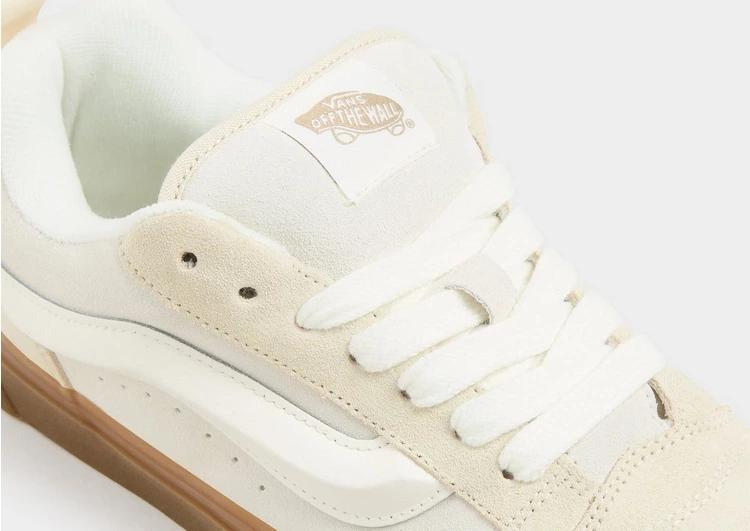

model_response
 candidates {
  content {
    role: "model"
    parts {
      text: " The product shown in the image is the Vans Chima Pro 2."
    }
  }
  finish_reason: STOP
  safety_ratings {
    category: HARM_CATEGORY_HATE_SPEECH
    probability: NEGLIGIBLE
    probability_score: 0.10447732359170914
    severity: HARM_SEVERITY_NEGLIGIBLE
    severity_score: 0.14235107600688934
  }
  safety_ratings {
    category: HARM_CATEGORY_DANGEROUS_CONTENT
    probability: NEGLIGIBLE
    probability_score: 0.1367236226797104
    severity: HARM_SEVERITY_NEGLIGIBLE
    severity_score: 0.09756221622228622
  }
  safety_ratings {
    category: HARM_CATEGORY_HARASSMENT
    probability: NEGLIGIBLE
    probability_score: 0.08678673952817917
    severity: HARM_SEVERITY_NEGLIGIBLE
    severity_score: 0.10158944875001907
  }
  safety_ratings {
    category: HARM_CATEGORY_SEXUALLY_EXPLICIT
    probability: NEGLIGIBLE
    probability_score: 0.06928940862417221
    severity: HARM_SEVERITY_NEGLIGIBLE
    seve

In [6]:
image_path = "gs://uk-bh-experiments-argolis-eu/trainers/jd_VN0009QCDBS1_d.webp" # @param {type:"string"}
test_image = getImageFromGSPath(image_path)

vertex_test_image = convertWebPtoVertexImage(test_image)
image2 = Part.from_image(vertex_test_image)
display(vertex_test_image)
model_response = model_gemini_pro_vision_10.generate_content(["what product is shown in these images?", image2])
print("model_response\n",model_response)

In [7]:
from google.cloud import translate as translate3

def translate_text(
    text: str = "YOUR_TEXT_TO_TRANSLATE", project_id: str = PROJECT_ID
) -> translate3.TranslationServiceClient:
    """Translating Text."""

    client = translate3.TranslationServiceClient()

    location = "global"

    parent = f"projects/{project_id}/locations/{location}"

    # Translate text from English to French
    # Detail on supported types can be found here:
    # https://cloud.google.com/translate/docs/supported-formats
    response = client.translate_text(
        request={
            "parent": parent,
            "contents": [text],
            "mime_type": "text/plain",  # mime types: text/plain, text/html
            "source_language_code": "en-US",
            "target_language_code": "es",
        }
    )

    # Display the translation for each input text provided
    for translation in response.translations:
        print(f"Translated text: {translation.translated_text}")

    return response

english_description = "Step into the future with the Nike Air Max 95. These men's trainers are a legendary silhouette that have been revamped with a modern twist. They feature a black upper with orange accents and a visible Air Max unit in the heel for cushioning. The rubber outsole provides traction and durability, while the iconic Nike branding adds a touch of style. Whether you're hitting the streets or just running errands, these trainers are a must-have for any sneakerhead."

translated_description = translate_text(english_description)

print(f'{translated_description=}')

Translated text: Da un paso hacia el futuro con las Nike Air Max 95. Estas zapatillas deportivas para hombre tienen una silueta legendaria que se ha renovado con un toque moderno. Cuentan con una parte superior negra con detalles en naranja y una unidad Air Max visible en el talón para amortiguación. La suela de goma brinda tracción y durabilidad, mientras que la icónica marca Nike agrega un toque de estilo. Ya sea que estés saliendo a la calle o simplemente haciendo recados, estas zapatillas son imprescindibles para cualquier amante de las zapatillas.
translated_description=translations {
  translated_text: "Da un paso hacia el futuro con las Nike Air Max 95. Estas zapatillas deportivas para hombre tienen una silueta legendaria que se ha renovado con un toque moderno. Cuentan con una parte superior negra con detalles en naranja y una unidad Air Max visible en el tal\303\263n para amortiguaci\303\263n. La suela de goma brinda tracci\303\263n y durabilidad, mientras que la ic\303\263nic